# LLM Vision Comparison on Makassar Road Segmentation Dataset

Compares **DeepSeek, xAI (Grok), OpenAI, and Claude** on a road-segmentation-style task using the [Makassar Road dataset](https://datasetninja.com/makassar-road).

**Important framing note:** none of these four are pixel-mask segmentation models (they're chat/vision LLMs, not models like SAM or U-Net). So "segmentation" here is operationalized as: *show the model an image, ask it to return a polygon (list of [x,y] points, normalized 0-1) outlining the road area*. We then:

- Rasterize that polygon into a binary mask
- Compare it to the dataset's ground-truth mask via **IoU / Dice**
- Record **latency**, **prompt/completion token usage**, and **cost** (using each provider's published per-token pricing, which you should double check/update below)

This gives you a fair, like-for-like comparison even though the task is a reasoning proxy for segmentation rather than true dense prediction.


In [32]:
# 1. Install dependencies
%pip install -q openai anthropic requests pillow numpy pandas matplotlib tqdm shapely


Note: you may need to restart the kernel to use updated packages.


In [33]:
# 2. Imports
import os, time, json, base64, io
from pathlib import Path
from dataclasses import dataclass, field
from typing import List, Tuple, Optional
from dotenv import load_dotenv

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from shapely.geometry import Polygon
from tqdm.auto import tqdm

import sys
print(sys.executable)


d:\Miniconda\miniconda3\envs\api-env\python.exe


## 3. Configuration

Set your API keys as environment variables (recommended) or fill them in directly (not recommended for shared notebooks).


In [34]:
# Load API keys from API_KEY.txt if it exists
if os.path.exists("API_KEY.txt"):
    with open("API_KEY.txt", "r") as f:
        for line in f:
            line = line.strip()
            if line and not line.startswith("#") and "=" in line:
                key, val = line.split("=", 1)
                os.environ[key.strip()] = val.strip()

load_dotenv()

# 3a. API keys (env vars preferred)
ANTHROPIC_API_KEY = os.getenv("ANTHROPIC_API_KEY", "")
OPENAI_API_KEY    = os.getenv("OPENAI_API_KEY",    "")
DEEPSEEK_API_KEY  = os.getenv("DEEPSEEK_API_KEY",  "")
XAI_API_KEY       = os.getenv("XAI_API_KEY",       "")

# Look up the right key by provider name. The run-loop used f"{provider.upper()}_API_KEY",
# which produced "CLAUDE_API_KEY" for Claude (the variable is ANTHROPIC_API_KEY) and so it
# silently skipped Claude every image. Map provider -> key explicitly instead.
API_KEYS = {
    "openai":   OPENAI_API_KEY,
    "claude":   ANTHROPIC_API_KEY,
    "xai":      XAI_API_KEY,
    "deepseek": DEEPSEEK_API_KEY,
}

# 3b. Model choices -- update to whichever current vision-capable model you have access to
MODELS = {
    "openai":   "gpt-4o",                # vision-capable
    "claude":   "claude-opus-4-6",     # vision-capable -- verify this slug is valid on your account
    "xai":      "grok-4",    # "grok-2-vision" 404s; this is the real API id -- verify current
    "deepseek": None,                    # DeepSeek's public API has no image_url vision endpoint
                                         # (it 400s on "unknown variant image_url"), so it is skipped.
}

# 3c. Pricing -- USD per 1M tokens. THESE CHANGE OFTEN, double check against each provider's
# live pricing page before trusting the cost numbers this notebook produces.
PRICING_PER_1M = {
    "openai":   {"input": 2.50,  "output": 10.00},
    "claude":   {"input": 3.00,  "output": 15.00},
    "xai":      {"input": 3.00,  "output": 15.00},
    "deepseek": {"input": 0.14,  "output": 0.28},
}

## 4. Dataset

Dataset Ninja's site is a *viewer*, not a direct download API -- grab the actual files from the page (it links to the original source/license) or via their export option, then point `DATA_DIR` below at the unzipped folder.

Expected layout (adjust the loader in 4b if yours differs):
```
data/
  img/        *.jpg / *.png        (raw road photos)
  ann/        *.json                (Supervisely-style annotations with polygon points for the "road" class)
```


In [35]:
# 4a. Paths -- update after you've downloaded/extracted the dataset locally
data_path = "../../data/makassar_road/ds"
DATA_DIR = Path(data_path)
IMG_DIR = DATA_DIR / "img"
ANN_DIR = DATA_DIR / "ann"

# How many images to evaluate per model (start small -- this costs real API credits)
N_SAMPLES = 20


In [36]:
# 4b. Ground truth loader
# The Makassar Road dataset (Supervisely / Dataset Ninja export) stores each object as a
# *bitmap* mask (base64 + zlib-compressed PNG plus an [x, y] origin), NOT polygon points.
# The old polygon loader always returned None here, which is why every IoU came back NaN and
# the overlay cell crashed on imshow(None). We decode the "road" bitmap and paste it onto a
# full-image mask instead.
import zlib

def _decode_supervisely_bitmap(bitmap: dict) -> np.ndarray:
    """Decode one Supervisely bitmap object -> boolean 2D array of the sub-region."""
    raw = zlib.decompress(base64.b64decode(bitmap["data"]))
    sub = np.array(Image.open(io.BytesIO(raw)))
    if sub.ndim == 3:          # RGBA / LA -> alpha channel is the mask
        return sub[:, :, -1] > 0
    return sub > 0             # P / L -> any non-zero pixel is foreground

def load_ground_truth_mask(ann_path: Path, size_wh=None,
                           road_class_names=("road", "Road")) -> Optional[np.ndarray]:
    """Return a full-image uint8 road mask (1 = road), or None if no road object is present."""
    with open(ann_path) as f:
        ann = json.load(f)
    w = ann.get("size", {}).get("width")
    h = ann.get("size", {}).get("height")
    if size_wh is not None:
        w, h = size_wh
    if not w or not h:
        return None
    mask = np.zeros((h, w), dtype=np.uint8)
    found = False
    for obj in ann.get("objects", []):
        if obj.get("classTitle") not in road_class_names:
            continue
        bmp = obj.get("bitmap")
        if not bmp:
            continue
        sub = _decode_supervisely_bitmap(bmp)
        ox, oy = bmp.get("origin", [0, 0])          # origin is [x (col), y (row)]
        y0, x0 = int(oy), int(ox)
        y1, x1 = min(y0 + sub.shape[0], h), min(x0 + sub.shape[1], w)
        mask[y0:y1, x0:x1] |= sub[: y1 - y0, : x1 - x0].astype(np.uint8)
        found = True
    return mask if found else None

def list_samples(n=N_SAMPLES):
    imgs = sorted(IMG_DIR.glob("*.*"))[:n]
    samples = []
    for img_path in imgs:
        ann_path = ANN_DIR / (img_path.name + ".json")
        if ann_path.exists():
            samples.append((img_path, ann_path))
    return samples

samples = list_samples()
print(f"Loaded {len(samples)} image/annotation pairs")

Loaded 20 image/annotation pairs


## 5. Prompting each model for a road polygon

All four providers get the **same image + same prompt**, asking for a JSON list of normalized `[x, y]` polygon points outlining the road surface. We measure wall-clock latency and parse token usage straight from each API's response object (no guessing/estimating).


In [37]:
PROMPT = (
    "Look at this road photo. Identify the drivable road surface area. "
    "Respond with ONLY a JSON object of the form "
    '{"polygon": [[x1,y1],[x2,y2],...]} '
    "where each x,y is normalized between 0 and 1 (0,0 = top-left of the image), "
    "tracing the outer boundary of the road surface. No prose, no markdown fences."
)

def encode_image_b64(path: Path) -> str:
    with open(path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")

def parse_polygon_response(text: str) -> Optional[List[Tuple[float, float]]]:
    text = text.strip()
    if text.startswith("```"):
        text = text.strip("`")
        text = text.replace("json", "", 1).strip()
    try:
        data = json.loads(text)
        pts = data.get("polygon", [])
        return [(float(x), float(y)) for x, y in pts] if pts else None
    except Exception:
        return None


In [38]:
# 5a. OpenAI call
def call_openai(image_path: Path, model: str):
    from openai import OpenAI
    client = OpenAI(api_key=OPENAI_API_KEY)
    b64 = encode_image_b64(image_path)
    t0 = time.time()
    resp = client.chat.completions.create(
        model=model,
        messages=[{
            "role": "user",
            "content": [
                {"type": "text", "text": PROMPT},
                {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{b64}"}},
            ],
        }],
        max_tokens=1000,
    )
    latency = time.time() - t0
    text = resp.choices[0].message.content
    usage = resp.usage
    return text, latency, usage.prompt_tokens, usage.completion_tokens


In [39]:
# 5b. Claude (Anthropic) call
def call_claude(image_path: Path, model: str):
    import anthropic
    # Load API keys from API_KEY.txt if it exists
    # if os.path.exists("API_KEY.txt"):
    #     with open("API_KEY.txt", "r") as f:
    #         for line in f:
    #             line = line.strip()
    #             if line and not line.startswith("#") and "=" in line:
    #                 key, val = line.split("=", 1)
    #                 os.environ[key.strip()] = val.strip() // For API_Key in txt file
        
    if not ANTHROPIC_API_KEY:
        raise ValueError("ANTHROPIC_API_KEY belum terbaca dari .env") # Loaded from .env

    client = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)
    b64 = encode_image_b64(image_path)
    media_type = "image/png" if image_path.suffix.lower() == ".png" else "image/jpeg"
    t0 = time.time()
    resp = client.messages.create(
        model=model,
        max_tokens=1000,
        messages=[{
            "role": "user",
            "content": [
                {"type": "image", "source": {"type": "base64", "media_type": media_type, "data": b64}},
                {"type": "text", "text": PROMPT},
            ],
        }],
    )
    latency = time.time() - t0
    text = "".join(block.text for block in resp.content if block.type == "text")
    return text, latency, resp.usage.input_tokens, resp.usage.output_tokens


In [40]:
# 5c. xAI (Grok) call -- OpenAI-compatible endpoint
def call_xai(image_path: Path, model: str):
    from openai import OpenAI
    client = OpenAI(api_key=XAI_API_KEY, base_url="https://api.x.ai/v1")
    b64 = encode_image_b64(image_path)
    t0 = time.time()
    resp = client.chat.completions.create(
        model=model,
        messages=[{
            "role": "user",
            "content": [
                {"type": "text", "text": PROMPT},
                {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{b64}"}},
            ],
        }],
        max_tokens=1000,
    )
    latency = time.time() - t0
    text = resp.choices[0].message.content
    usage = resp.usage
    return text, latency, usage.prompt_tokens, usage.completion_tokens


In [41]:
# 5d. DeepSeek call -- OpenAI-compatible endpoint
# NOTE: verify DeepSeek currently exposes a vision-capable model on your account/tier.
# If not, set MODELS["deepseek"] = None above and this provider will be skipped.
def call_deepseek(image_path: Path, model: str):
    from openai import OpenAI
    client = OpenAI(api_key=DEEPSEEK_API_KEY, base_url="https://api.deepseek.com")
    b64 = encode_image_b64(image_path)
    t0 = time.time()
    resp = client.chat.completions.create(
        model=model,
        messages=[{
            "role": "user",
            "content": [
                {"type": "text", "text": PROMPT},
                {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{b64}"}},
            ],
        }],
        max_tokens=1000,
    )
    latency = time.time() - t0
    text = resp.choices[0].message.content
    usage = resp.usage
    return text, latency, usage.prompt_tokens, usage.completion_tokens

PROVIDER_FUNCS = {
    "openai": call_openai,
    "claude": call_claude,
    "xai": call_xai,
    "deepseek": call_deepseek,
}


## 6. Metrics: IoU/Dice between predicted and ground-truth masks


In [42]:
def polygon_to_mask(polygon_norm, size_wh):
    w, h = size_wh
    if not polygon_norm:
        return np.zeros((h, w), dtype=np.uint8)
    pts = [(x * w, y * h) for x, y in polygon_norm]
    mask_img = Image.new("L", (w, h), 0)
    ImageDraw.Draw(mask_img).polygon(pts, outline=1, fill=1)
    return np.array(mask_img, dtype=np.uint8)

def gt_polygon_to_mask(polygon_px, size_wh):
    w, h = size_wh
    mask_img = Image.new("L", (w, h), 0)
    ImageDraw.Draw(mask_img).polygon(polygon_px, outline=1, fill=1)
    return np.array(mask_img, dtype=np.uint8)

def iou_dice(pred_mask, gt_mask):
    pred = pred_mask.astype(bool)
    gt = gt_mask.astype(bool)
    inter = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    iou = inter / union if union > 0 else 0.0
    dice = (2 * inter) / (pred.sum() + gt.sum()) if (pred.sum() + gt.sum()) > 0 else 0.0
    return float(iou), float(dice)


## 7. Run the comparison

This loops every sample image through every configured provider, records latency/tokens/cost/IoU, and stores everything in a tidy DataFrame. **This calls paid APIs** -- start with a small `N_SAMPLES` above before scaling up.


In [43]:
rows = []

for img_path, ann_path in tqdm(samples, desc="images"):
    img = Image.open(img_path).convert("RGB")
    size_wh = img.size
    gt_mask = load_ground_truth_mask(ann_path, size_wh)

    for provider, model in MODELS.items():
        if model is None:
            continue
        if not API_KEYS.get(provider):
            print(f"Skipping {provider}: no API key set")
            continue
        try:
            text, latency, ptoks, ctoks = PROVIDER_FUNCS[provider](img_path, model)
        except Exception as e:
            print(f"{provider} failed on {img_path.name}: {e}")
            continue

        pred_poly = parse_polygon_response(text)
        if pred_poly and gt_mask is not None:
            pred_mask = polygon_to_mask(pred_poly, size_wh)
            iou, dice = iou_dice(pred_mask, gt_mask)
        else:
            iou, dice = None, None

        price = PRICING_PER_1M[provider]
        cost = (ptoks / 1_000_000) * price["input"] + (ctoks / 1_000_000) * price["output"]

        rows.append({
            "image": img_path.name,
            "provider": provider,
            "model": model,
            "latency_sec": latency,
            "prompt_tokens": ptoks,
            "completion_tokens": ctoks,
            "total_tokens": ptoks + ctoks,
            "cost_usd": cost,
            "iou": iou,
            "dice": dice,
            "parsed_ok": pred_poly is not None,
        })

df = pd.DataFrame(rows)
df.to_csv("result/results.csv", index=False)
df.head()

images:   0%|          | 0/20 [00:00<?, ?it/s]

,image,provider,model,latency_sec,prompt_tokens,completion_tokens,total_tokens,cost_usd,iou,dice,parsed_ok
0,0060_Image1.jpg,openai,gpt-4o,2.924524,1190,53,1243,0.003505,0.306378,0.469049,True
1,0060_Image1.jpg,claude,claude-opus-4-6,6.127315,1652,287,1939,0.009261,0.341448,0.509074,True
2,0060_Image1.jpg,xai,grok-4,10.567530,2691,69,2760,0.009108,0.380858,0.551625,True
3,0060_Image10.jpg,openai,gpt-4o,1.336291,1190,37,1227,0.003345,0.328427,0.494460,True
4,0060_Image10.jpg,claude,claude-opus-4-6,7.213274,1652,397,2049,0.010911,0.414894,0.586467,True


## 8. Summary table -- performance, latency, tokens, cost per provider


In [44]:
summary = df.groupby("provider").agg(
    mean_iou=("iou", "mean"),
    mean_dice=("dice", "mean"),
    parse_success_rate=("parsed_ok", "mean"),
    mean_latency_sec=("latency_sec", "mean"),
    p95_latency_sec=("latency_sec", lambda s: s.quantile(0.95)),
    mean_prompt_tokens=("prompt_tokens", "mean"),
    mean_completion_tokens=("completion_tokens", "mean"),
    total_tokens=("total_tokens", "sum"),
    total_cost_usd=("cost_usd", "sum"),
    n_images=("image", "count"),
).round(4)

summary


,mean_iou,mean_dice,parse_success_rate,mean_latency_sec,p95_latency_sec,mean_prompt_tokens,mean_completion_tokens,total_tokens,total_cost_usd,n_images
provider,,,,,,,,,,
claude,0.4054,0.5761,1.00,7.0850,8.1161,1652.0,370.5,40450,0.2103,20
openai,0.3228,0.4745,0.95,1.9341,2.9621,1190.0,44.8,24696,0.0685,20
xai,0.4270,0.5963,1.00,11.0278,13.2709,2691.0,75.8,55336,0.1842,20


## 9. Charts


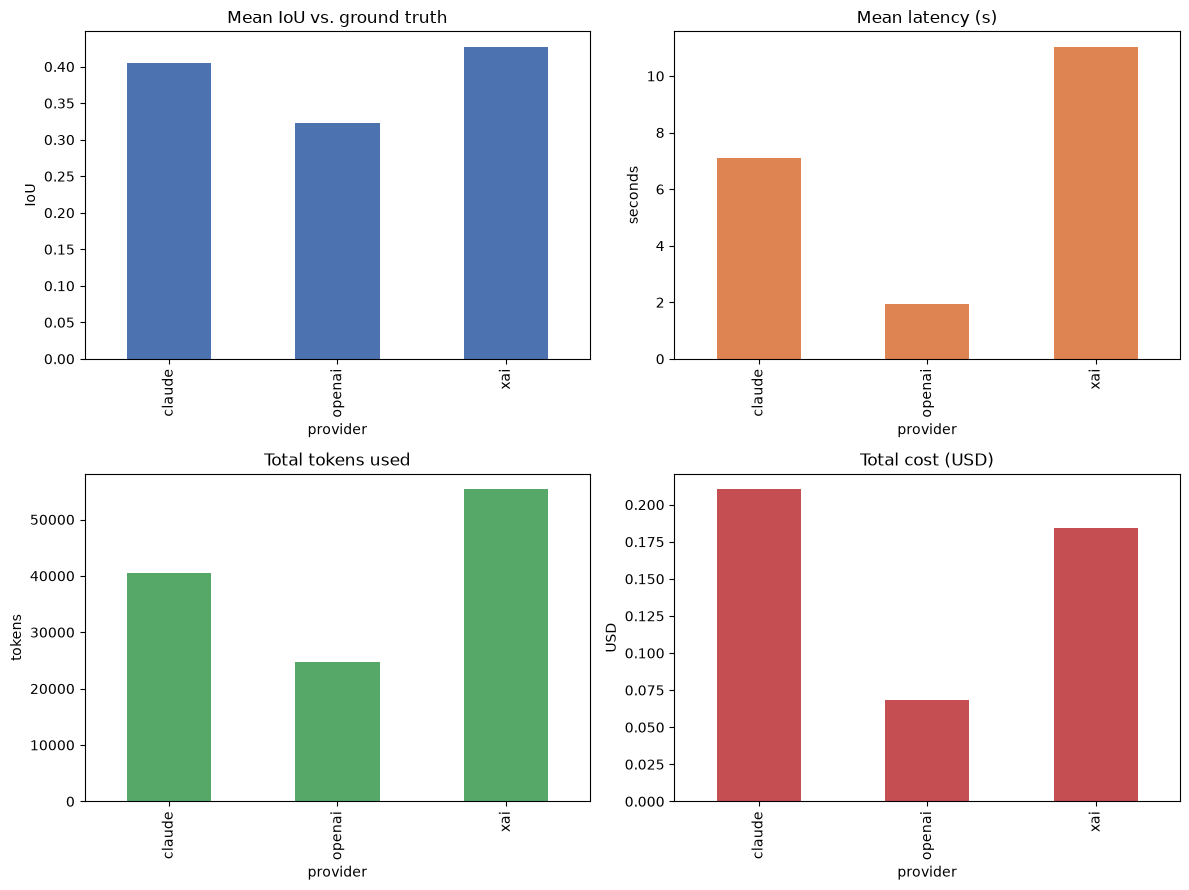

In [45]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

summary["mean_iou"].plot(kind="bar", ax=axes[0,0], title="Mean IoU vs. ground truth", color="#4C72B0")
axes[0,0].set_ylabel("IoU")

summary["mean_latency_sec"].plot(kind="bar", ax=axes[0,1], title="Mean latency (s)", color="#DD8452")
axes[0,1].set_ylabel("seconds")

summary["total_tokens"].plot(kind="bar", ax=axes[1,0], title="Total tokens used", color="#55A868")
axes[1,0].set_ylabel("tokens")

summary["total_cost_usd"].plot(kind="bar", ax=axes[1,1], title="Total cost (USD)", color="#C44E52")
axes[1,1].set_ylabel("USD")

plt.tight_layout()
plt.savefig("fig/comparison_charts.png", dpi=150)
plt.show()


## 10. Visual sanity check -- predicted vs. ground-truth mask overlay

Spot-check a handful of predictions side-by-side so low IoU scores are interpretable (e.g. is the model's polygon genuinely off, or did parsing just fail on malformed JSON?).


--- OpenAI Overlay --- 


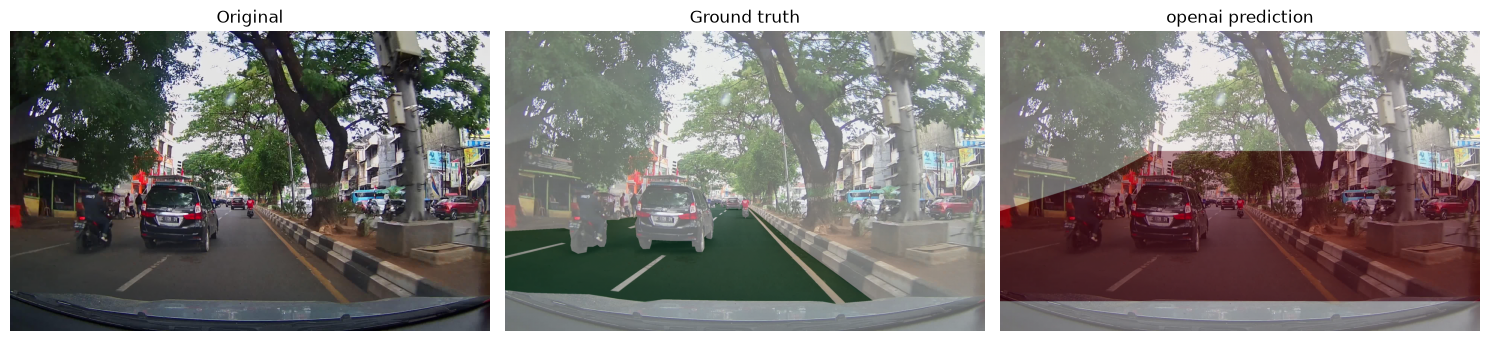

--- Claude Overlay --- 


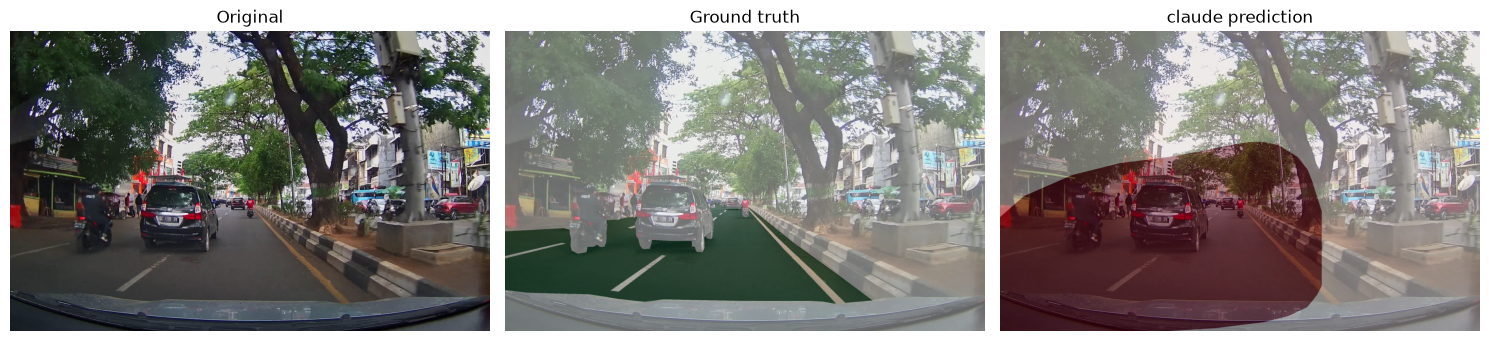

--- xAI Overlay --- 


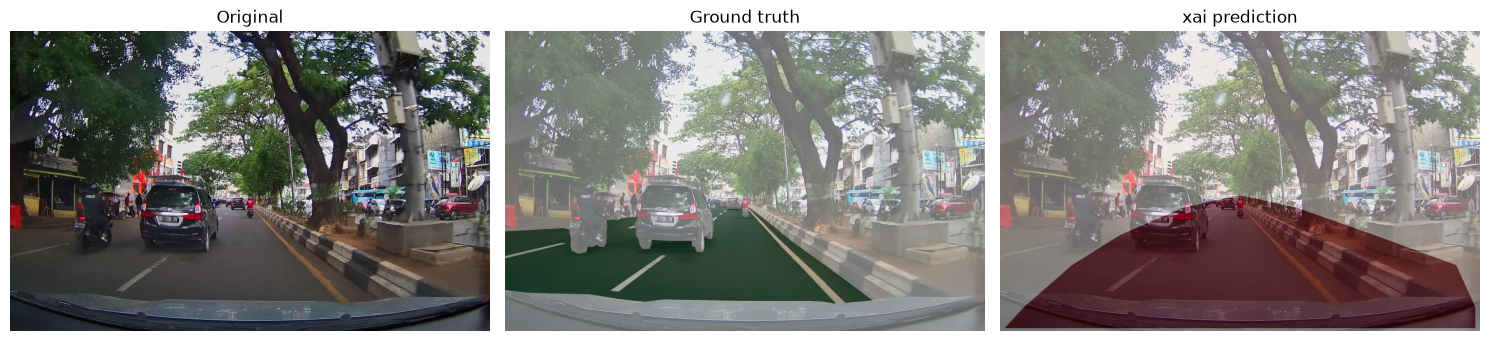

In [46]:
def show_overlay(img_path: Path, ann_path: Path, provider: str, model: str):
    img = Image.open(img_path).convert("RGB")
    size_wh = img.size
    gt_mask = load_ground_truth_mask(ann_path, size_wh)

    text, latency, ptoks, ctoks = PROVIDER_FUNCS[provider](img_path, model)
    pred_poly = parse_polygon_response(text)
    pred_mask = polygon_to_mask(pred_poly, size_wh) if pred_poly else None

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img); axes[0].set_title("Original"); axes[0].axis("off")

    axes[1].imshow(img)
    if gt_mask is not None:
        axes[1].imshow(gt_mask, alpha=0.4, cmap="Greens")
    axes[1].set_title("Ground truth" if gt_mask is not None else "Ground truth (none)")
    axes[1].axis("off")

    axes[2].imshow(img)
    if pred_mask is not None and pred_mask.any():
        axes[2].imshow(pred_mask, alpha=0.4, cmap="Reds")
    axes[2].set_title(f"{provider} prediction")
    axes[2].axis("off")

    plt.tight_layout(); plt.show()

# Example:
if MODELS.get("openai") and API_KEYS.get("openai"):
    print("--- OpenAI Overlay --- ")
    show_overlay(samples[0][0], samples[0][1], "openai", MODELS["openai"])

if MODELS.get("claude") and API_KEYS.get("claude"):
    print("--- Claude Overlay --- ")
    show_overlay(samples[0][0], samples[0][1], "claude", MODELS["claude"])

if MODELS.get("xai") and API_KEYS.get("xai"):
    print("--- xAI Overlay --- ")
    show_overlay(samples[0][0], samples[0][1], "xai", MODELS["xai"])
